In [56]:
# Configure path.
import sys; import os
sys.path.append(os.path.abspath('..'))

%matplotlib inline
import numpy as np
import importlib, pickle
import matplotlib.pyplot as plt
plt.style.use('dissertation.mplstyle')

from python import forces, integrators, random_matrix, simulate, densities, plotters
importlib.reload(forces); importlib.reload(integrators); importlib.reload(random_matrix)
importlib.reload(simulate); importlib.reload(densities); importlib.reload(plotters);

---

1. Eigenvalues of a large Hermitian matrix.

In [ ]:
M = 1; N = 5000;
eigs = random_matrix.init_gue_eigenvalues(M, N).flatten()

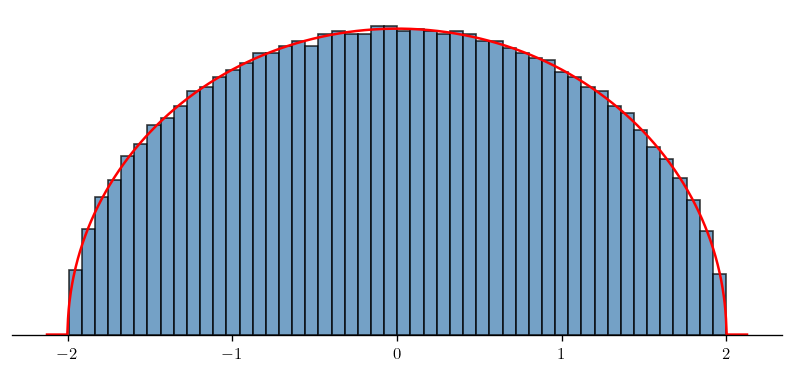

In [10]:
fig, ax = plt.subplots()
plotters.plot_hist(ax, eigs, num_bins = 50, potential_name = "quadratic")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])

plt.savefig("figures/eigs-random-N5000.pdf", format = "pdf", dpi = 120)
plt.show()

---

2. Unadjusted methods.

Tamed: $N=30$ and $N = 100$ for $dt = 1/N, 1/N^2$, empirical densities and distance metrics.

In [ ]:
importlib.reload(densities);
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 100; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)
dt = 1/(N**3/2); total_steps = int(T/dt); 

config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks"}

tamed_pipe_1a = simulate.get_pipeline("tamed", N = N, dt = dt, potential_type = pot_name, beta = beta)
trajectory_1a = simulate.simulate_dbm(init, total_steps, tamed_pipe_1a)
info_1a = simulate.analyse_trajectory(trajectory_1a, total_steps, **config)

dt = 1/(N**2); total_steps = int(T/dt); 
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks"}

tamed_pipe_1b = simulate.get_pipeline("tamed", N = N, dt = dt, potential_type = pot_name, beta = beta)
trajectory_1b = simulate.simulate_dbm(init, total_steps, tamed_pipe_1b)
info_1b = simulate.analyse_trajectory(trajectory_1b, total_steps, **config)

In [ ]:
importlib.reload(plotters);
fig, axes = plt.subplots(1, 2, figsize = (10, 3))
ax1, ax2 = axes

plotters.plot_hist(ax1, np.clip(info_1a["snapshots"], -2, 2), num_bins = num_bins, potential_name = pot_name)
plotters.plot_hist(ax2, np.clip(info_1b["snapshots"], -2, 2), num_bins = num_bins, potential_name = pot_name)

ax1.set_title(r"$\Delta t = 1/N\sqrt{N}$", fontsize = 15)
ax2.set_title(r"$\Delta t = 1/N^2$", fontsize = 15)

for ax in axes:
    ax.grid(False)

plt.show()

---


In [8]:
# Implicit and implicit midpoint: use dt = 0.1 (O(1)) and track the distance metrics for large N (50, 100, 200)
# then compare this to when using 1/sqrt{N} and 1/N.
# Uses default Newton tol 1e-6 and cg tol 1e-9...
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 100; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)

dt = 0.1; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_1a = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_1a = simulate.simulate_dbm(init, total_steps, implicit_pipe_1a)
implicit_info_1a = simulate.analyse_trajectory(implicit_traj_1a, total_steps, **config)

# =========================================================================================================
dt = 1/np.sqrt(N); total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_1b = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_1b = simulate.simulate_dbm(init, total_steps, implicit_pipe_1b)
implicit_info_1b = simulate.analyse_trajectory(implicit_traj_1b, total_steps, **config)

# =========================================================================================================
dt = 1/N; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_1c = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_1c = simulate.simulate_dbm(init, total_steps, implicit_pipe_1c)
implicit_info_1c = simulate.analyse_trajectory(implicit_traj_1c, total_steps, **config)

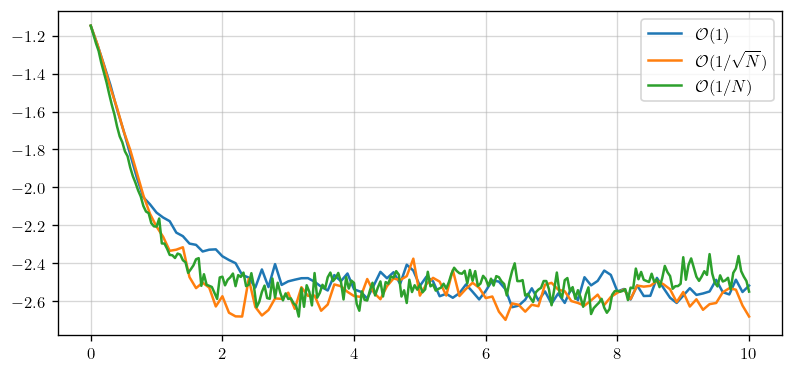

In [ ]:
# For N = 100, 0.1 and 1/root(100) are the same!
fig, ax = plt.subplots(1, 1, figsize = (6.5, 3))
importlib.reload(plotters);
plotters.plot_distances(ax, implicit_info_1a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax, implicit_info_1b, label = r"$\mathcal{O}(1/\sqrt{N})$")
plotters.plot_distances(ax, implicit_info_1c, label = r"$\mathcal{O}(1/N)$")

ax.legend()
plt.show()

Run again for larger $N$, still implicit (try $N = 300$, e.g.).

In [ ]:
# Implicit and implicit midpoint: use dt = 0.1 (O(1)) and track the distance metrics for large N (50, 100, 200)
# then compare this to when using 1/sqrt{N} and 1/N.
# Uses default Newton tol 1e-6 and cg tol 1e-9...
beta = 2.0; T = 10.0; M = 50; pot_name = "quartic"; num_bins = 50
grid = np.linspace(-2, 2, 1000); 

N = 300; init = random_matrix.init_gue_eigenvalues(M, N)
F_exact = densities.compute_exact_cdf(N, pot_name, grid)

dt = 0.1; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2a = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2a = simulate.simulate_dbm(init, total_steps, implicit_pipe_2a)
implicit_info_2a = simulate.analyse_trajectory(implicit_traj_2a, total_steps, **config)

print(f"Onto 1/rootN.")
# =========================================================================================================
dt = 1/np.sqrt(N); total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2b = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2b = simulate.simulate_dbm(init, total_steps, implicit_pipe_2b)
implicit_info_2b = simulate.analyse_trajectory(implicit_traj_2b, total_steps, **config)

print(f"Onto 1/N.")
# =========================================================================================================
dt = 1/N; total_steps = int(T/dt)
config = {"burn_in": int(2.0/dt), "snapshot_interval": 10,
          "track_distance": True, "dt": dt, "grid": grid, "F_exact": F_exact, "distance_type": "ks",
          "track_newton_info": True}
implicit_pipe_2c = simulate.get_pipeline("implicit", N = N, dt = dt, potential_type = pot_name, beta = beta)
implicit_traj_2c = simulate.simulate_dbm(init, total_steps, implicit_pipe_2c)
implicit_info_2c = simulate.analyse_trajectory(implicit_traj_2c, total_steps, **config)

Onto 1/rootN.
Onto 1/N.


N = 100-300, M = 50, T = 10, all implicit.


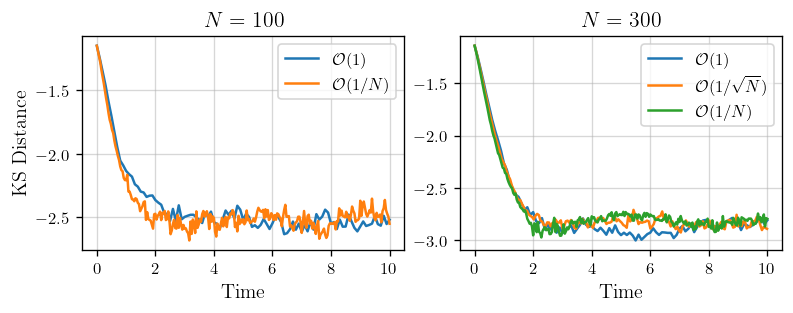

In [57]:
print(f"N = 100-300, M = 50, T = 10, all implicit.")

fig, axes = plt.subplots(1, 2, figsize = (6.5, 2.5))
ax, ax2 = axes

plotters.plot_distances(ax, implicit_info_1a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax, implicit_info_1c, label = r"$\mathcal{O}(1/N)$")

plotters.plot_distances(ax2, implicit_info_2a, label = r"$\mathcal{O}(1)$")
plotters.plot_distances(ax2, implicit_info_2b, label = r"$\mathcal{O}(1/\sqrt{N})$")
plotters.plot_distances(ax2, implicit_info_2c, label = r"$\mathcal{O}(1/N)$")

ax.set_title(r"$N = 100$")
ax2.set_title(r"$N = 300$")
ax.set_ylabel("KS Distance")

for ax in axes:
    ax.legend()
    ax.set_xlabel("Time")

plt.savefig("a-implicit_N100-300-T10-distances.pdf", format = "pdf", dpi = 120)
plt.show()

Does the step size influence the number of Newton/CG iterations needed as $N$ grows?

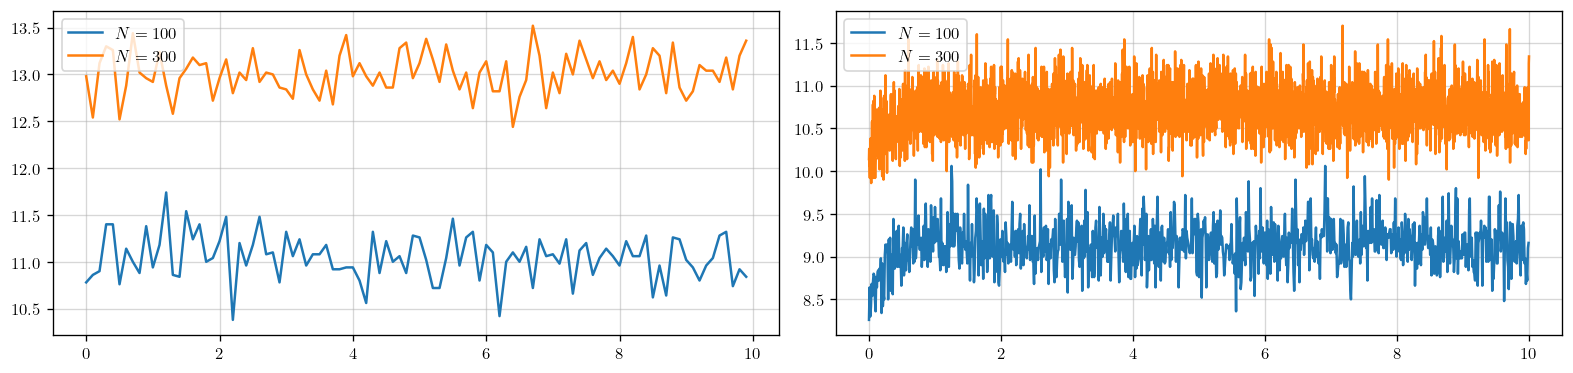

In [51]:
dt = 0.1; step_times_O1 = [step*dt for step in range(int(T/dt))]
dt = 1/100; step_times_N100 = [step*dt for step in range(int(T/dt))]
dt = 1/300; step_times_N300 = [step*dt for step in range(int(T/dt))]

fig, axes = plt.subplots(1, 2, figsize = (13, 3))
ax1, ax2 = axes 

ax1.plot(step_times_O1, implicit_info_1a["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)
ax2.plot(step_times_N100, implicit_info_1c["newton_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax2.plot(step_times_N300, implicit_info_2c["newton_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5)

for ax in axes:
    ax.legend(loc = "upper left")

plt.show()

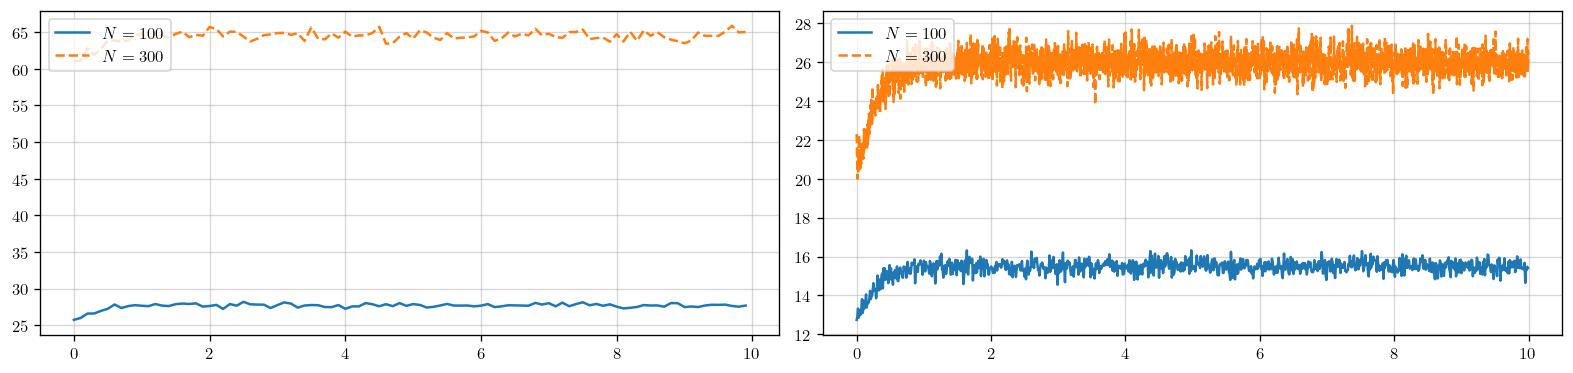

In [50]:
fig, axes = plt.subplots(1, 2, figsize = (13, 3))
ax1, ax2 = axes 

ax1.plot(step_times_O1, implicit_info_1a["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax1.plot(step_times_O1, implicit_info_2a["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5, linestyle = "--")
ax2.plot(step_times_N100, implicit_info_1c["mean_cg_iters"].mean(axis = 1), label = r"$N = 100$", lw = 1.5)
ax2.plot(step_times_N300, implicit_info_2c["mean_cg_iters"].mean(axis = 1), label = r"$N = 300$", lw = 1.5, linestyle = "--")

for ax in axes:
    ax.legend(loc = "upper left")

plt.show()

In [19]:
implicit_N100 = {
    "N": 100, "M": 50, "T": 10,
    "dt-O1": implicit_info_1a,
    "dt-O1overN": implicit_info_1c
}

implicit_N300 = {
    "N": 300, "M": 50, "T": 10,
    "dt-O1": implicit_info_2a,
    "dt-O1rootN": implicit_info_2b,
    "dt-O1overN": implicit_info_2c
}

all_implicit_data = {
    "N100": implicit_N100,
    "N300": implicit_N300,
    "M": 50, "T": 10, 
}

filename = f"data/implicit-N100-300.pkl"
with open(filename, 'wb') as f:
    pickle.dump(all_implicit_data, f)

---
---
---
---
---